# 11 — Predicción CAR a resolución del DEM (50 m)

Este notebook toma los resultados del modelo CAR Leroux ajustado en
`11_CAR_altiplanos_v2.ipynb` (resolución de 5 km) y los transforma en una
predicción a nivel de **píxel de 50 m** sobre **toda** la zona de estudio.

**Estrategia:**
1. Rasterizar el efecto espacial φ del CAR a 50 m (cada píxel recibe el valor
   de su celda de 5 km).
2. Entrenar un modelo logístico a nivel de píxel: `Altiplano ~ Altitud + Pendiente + Relieve + φ_CAR`.
3. Aplicar ese modelo a todos los píxeles válidos del DEM → GeoTIFF de probabilidad
   a 50 m.

De este modo se combinan:
- la **autocorrelación espacial** capturada por el CAR (a escala areal), y
- el **detalle topográfico** de cada píxel individual.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize
from rasterio.transform import array_bounds
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
import statsmodels.api as sm

warnings.filterwarnings("ignore")

RAIZ = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial"
CARPETA_RASTER = os.path.join(RAIZ, r"Raster\50m_UTM\Analisis")
CARPETA_RESULTADOS = os.path.join(RAIZ, "Resultados")
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "11_CAR_prediccion_total_v2")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

SEMILLA = 42
N_MUESTRA = 300_000
np.random.seed(SEMILLA)

print(f"Carpeta de figuras: {CARPETA_FIGURAS}")

Carpeta de figuras: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_prediccion_total_v2


## 1. Carga de rasters de referencia

In [2]:
t_inicio = time.time()

with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

with rasterio.open(f"{CARPETA_RASTER}\\Slp_NA_50.tif") as src:
    pendiente = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_pend = src.nodata

with rasterio.open(f"{CARPETA_RASTER}\\Rel_NA_5.tif") as src:
    relieve = src.read(1, out_shape=ref_shape).astype(np.float32)
    nodata_rel = src.nodata

with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs

altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
reproject(
    source=altiplano_original, destination=altiplano_alineado,
    src_transform=altiplano_transform, src_crs=altiplano_crs,
    dst_transform=ref_transform, dst_crs=ref_crs,
    resampling=Resampling.nearest, src_nodata=altiplano_nodata, dst_nodata=0,
)

mascara_valida = (altitud != dem_nodata) & (pendiente != nodata_pend) & (relieve != nodata_rel)
y_altiplano_mapa = (altiplano_alineado == 1) & mascara_valida
n_altiplano = y_altiplano_mapa.sum()
n_valido = mascara_valida.sum()
print(f"Grilla: {ref_shape} | Validos: {n_valido:,} ({100*n_valido/mascara_valida.size:.1f}%)")
print(f"Altiplano=1: {n_altiplano:,} ({100*n_altiplano/n_valido:.1f}%)")
print(f"Area valida: {n_valido * (abs(ref_transform.a)**2) / 1e6:,.0f} km2")

Grilla: (8276, 6084) | Validos: 24,783,966 (49.2%)
Altiplano=1: 3,746,338 (15.1%)
Area valida: 61,960 km2


## 2. Exploración de los datos

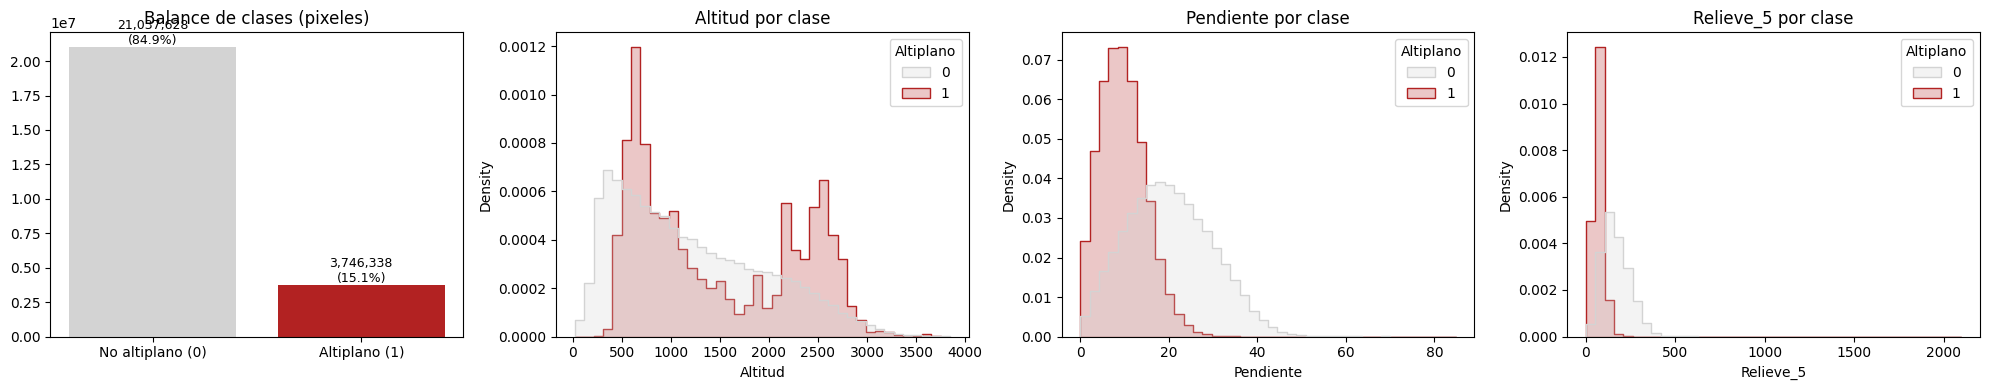

In [3]:
filas, cols = np.where(mascara_valida)
idx_hist = np.random.choice(len(filas), size=200_000, replace=False)
fh, ch = filas[idx_hist], cols[idx_hist]
tabla_hist = pd.DataFrame({
    "Altitud": altitud[fh, ch], "Pendiente": pendiente[fh, ch],
    "Relieve_5": relieve[fh, ch],
    "Altiplano": y_altiplano_mapa[fh, ch].astype(int),
})

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colores_clase = {0: "lightgray", 1: "firebrick"}
conteo = pd.Series([n_valido - n_altiplano, n_altiplano], index=[0, 1])
barras = axes[0].bar(["No altiplano (0)", "Altiplano (1)"], conteo.values,
                     color=[colores_clase[0], colores_clase[1]])
for b, v in zip(barras, conteo.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height(),
                 f"{v:,}\n({100*v/n_valido:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Balance de clases (pixeles)")
for ax, var in zip(axes[1:], ["Altitud", "Pendiente", "Relieve_5"]):
    sns.histplot(data=tabla_hist, x=var, hue="Altiplano", bins=40, palette=colores_clase,
                 ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(f"{var} por clase")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_predictores.png"), dpi=150)
plt.show()

## 3. Rasterización del efecto espacial CAR (5 km → 50 m)

Se carga el GeoPackage de celdas del CAR (`celdas_car_v2.gpkg`) y se rasteriza
el efecto aleatorio φ a la resolución del DEM (50 m). Cada píxel recibe el valor
de la celda de 5 km que lo contiene. Para píxeles fuera de la malla de celdas
(bordes recortados) se asigna φ = 0 (efecto espacial neutro).

La capa φ rasterizada se exporta como un GeoTIFF independiente que puede
usarse como insumo en otros modelos.

In [4]:
gdf_car = gpd.read_file(os.path.join(CARPETA_RESULTADOS, "celdas_car_v2.gpkg"))
print(f"Celdas CAR cargadas: {len(gdf_car)}")

# Rasterizar phi (efecto espacial) → fill=0 = efecto neutro fuera de celdas
phi_50m = rasterize(
    [(geom, val) for geom, val in zip(gdf_car.geometry, gdf_car["phi"])],
    out_shape=ref_shape, transform=ref_transform, fill=0.0, dtype="float32",
)
# Rasterizar probabilidad directa del CAR M1 (mejor DIC)
prob_car_directo = rasterize(
    [(geom, val) for geom, val in zip(gdf_car.geometry, gdf_car["prob_m1"])],
    out_shape=ref_shape, transform=ref_transform, fill=np.nan, dtype="float32",
)

phi_50m = np.where(mascara_valida, phi_50m, np.nan).astype(np.float32)
prob_car_directo = np.where(mascara_valida, prob_car_directo, np.nan).astype(np.float32)

n_con_phi = np.isfinite(phi_50m[mascara_valida]).sum()
print(f"Pixeles validos con phi: {n_con_phi:,} de {n_valido:,} ({100*n_con_phi/n_valido:.1f}%)")
print(f"  phi rango: [{np.nanmin(phi_50m):.3f}, {np.nanmax(phi_50m):.3f}]")
print(f"  prob_car rango: [{np.nanmin(prob_car_directo):.3f}, {np.nanmax(prob_car_directo):.3f}]")

# Exportar phi como capa raster reutilizable
ruta_phi = os.path.join(CARPETA_RESULTADOS, "car_phi_50m_v2.tif")
perfil = {"driver": "GTiff", "height": ref_shape[0], "width": ref_shape[1],
          "count": 1, "dtype": "float32", "crs": ref_crs, "transform": ref_transform,
          "nodata": np.nan, "compress": "lzw"}
with rasterio.open(ruta_phi, "w", **perfil) as dst:
    dst.write(phi_50m, 1)
print(f"\nCapa phi exportada: {ruta_phi}")

Celdas CAR cargadas: 2596


Pixeles validos con phi: 24,783,966 de 24,783,966 (100.0%)
  phi rango: [-13.755, 19.222]
  prob_car rango: [0.000, 1.000]



Capa phi exportada: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\car_phi_50m_v2.tif


## 4. Modelo logístico a nivel de píxel con efecto CAR

Se entrenan dos modelos sobre una muestra de 300 000 píxeles:

| Modelo | Predictores |
|---|---|
| **Base** | Altitud, Pendiente, Relieve |
| **CAR-Pixel** | Altitud, Pendiente, Relieve, **φ_CAR** |

El efecto φ_CAR actúa como un *prior espacial suavizado*: captura la
autocorrelación del CAR a escala de 5 km, mientras que las covariables
topográficas aportan el detalle fino a 50 m.

In [5]:
idx_muestra = np.random.choice(len(filas), size=N_MUESTRA, replace=False)
fs, cs = filas[idx_muestra], cols[idx_muestra]
y_sample = y_altiplano_mapa[fs, cs].astype(int)

# --- Modelo BASE (sin phi) ---
X_base = np.column_stack([altitud[fs, cs], pendiente[fs, cs], relieve[fs, cs]])
escalador_base = StandardScaler()
X_base_std = escalador_base.fit_transform(X_base)
modelo_base = sm.Logit(y_sample, sm.add_constant(X_base_std)).fit(disp=0)

# --- Modelo CAR-Pixel (con phi) ---
phi_sample = phi_50m[fs, cs]
X_phi = np.column_stack([altitud[fs, cs], pendiente[fs, cs], relieve[fs, cs], phi_sample])
escalador_phi = StandardScaler()
X_phi_std = escalador_phi.fit_transform(X_phi)
modelo_carpx = sm.Logit(y_sample, sm.add_constant(X_phi_std)).fit(disp=0)

print("=== MODELO BASE (sin CAR) ===")
print(modelo_base.summary(xname=["const", "Altitud", "Pendiente", "Relieve"]))
print("\n\n=== MODELO CAR-PIXEL (con phi como covariable) ===")
print(modelo_carpx.summary(xname=["const", "Altitud", "Pendiente", "Relieve", "CAR_phi"]))

=== MODELO BASE (sin CAR) ===


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               300000
Model:                          Logit   Df Residuals:                   299996
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Jul 2026   Pseudo R-squ.:                  0.4829
Time:                        06:58:36   Log-Likelihood:                -65862.
converged:                       True   LL-Null:                   -1.2738e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3693      0.019   -224.353      0.000      -4.407      -4.331
Altitud        1.0212      0.007    137.691      0.000       1.007       1.036
Pendiente     -0.0488      0.014     -3.451      0.0

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               300000
Model:                          Logit   Df Residuals:                   299995
Method:                           MLE   Df Model:                            4
Date:                Wed, 29 Jul 2026   Pseudo R-squ.:                  0.6455
Time:                        06:58:38   Log-Likelihood:                -45155.
converged:                       True   LL-Null:                   -1.2738e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.7787      0.029   -200.118      0.000      -5.835      -5.722
Altitud        1.8495      0.012    157.141      0.000       1.826       1.873
Pendiente     -0.3709      0.017    -21.919      0.0

## 5. Predicción sobre todo el DEM

In [6]:
CHUNK = 500_000
prob_base_full = np.full(ref_shape, np.nan, dtype=np.float32)
prob_carpx_full = np.full(ref_shape, np.nan, dtype=np.float32)

t0 = time.time()
for i in range(0, len(filas), CHUNK):
    sl = slice(i, min(i + CHUNK, len(filas)))
    fi, ci = filas[sl], cols[sl]

    xb = escalador_base.transform(np.column_stack([altitud[fi, ci], pendiente[fi, ci], relieve[fi, ci]]))
    prob_base_full[fi, ci] = modelo_base.predict(sm.add_constant(xb))

    xp = escalador_phi.transform(np.column_stack([altitud[fi, ci], pendiente[fi, ci],
                                                   relieve[fi, ci], phi_50m[fi, ci]]))
    prob_carpx_full[fi, ci] = modelo_carpx.predict(sm.add_constant(xp))

print(f"Prediccion sobre {len(filas):,} pixeles en {time.time()-t0:.1f}s")

Prediccion sobre 24,783,966 pixeles en 55.6s


In [7]:
y_all = y_altiplano_mapa[mascara_valida].astype(int)
pb = prob_base_full[mascara_valida]
pc = prob_carpx_full[mascara_valida]
pd_mask = np.isfinite(prob_car_directo[mascara_valida])
pd_vals = prob_car_directo[mascara_valida]

auc_base = roc_auc_score(y_all, pb)
auc_carpx = roc_auc_score(y_all, pc)
auc_car_dir = roc_auc_score(y_all[pd_mask], pd_vals[pd_mask])

def metricas(y, p, nombre, umbral=0.5):
    yp = (p >= umbral).astype(int)
    rep = classification_report(y, yp, target_names=["No altiplano", "Altiplano"],
                                output_dict=True, zero_division=0)
    auc = roc_auc_score(y, p)
    return {"Modelo": nombre, "AUC": auc,
            "Recall_Altiplano": rep["Altiplano"]["recall"],
            "Precision_Altiplano": rep["Altiplano"]["precision"],
            "F1_Altiplano": rep["Altiplano"]["f1-score"],
            "Accuracy": rep["accuracy"]}

tabla = pd.DataFrame([
    metricas(y_all, pb, "Logistico base (sin CAR)"),
    metricas(y_all, pc, "CAR-Pixel (logistico + phi)"),
    metricas(y_all[pd_mask], pd_vals[pd_mask], "CAR directo rasterizado (5 km)"),
])
print("COMPARACION DE MODELOS (evaluacion sobre TODOS los pixeles validos):")
print(tabla.round(4).to_string(index=False))

print(f"\nPseudo R2 McFadden:  base={modelo_base.prsquared:.4f}  CAR-Pixel={modelo_carpx.prsquared:.4f}")
print(f"AIC:                 base={modelo_base.aic:.0f}  CAR-Pixel={modelo_carpx.aic:.0f}")

COMPARACION DE MODELOS (evaluacion sobre TODOS los pixeles validos):
                        Modelo    AUC  Recall_Altiplano  Precision_Altiplano  F1_Altiplano  Accuracy
      Logistico base (sin CAR) 0.9364            0.5518               0.7073        0.6200    0.8977
   CAR-Pixel (logistico + phi) 0.9717            0.7646               0.8090        0.7862    0.9371
CAR directo rasterizado (5 km) 0.9400            0.8682               0.5841        0.6984    0.8863

Pseudo R2 McFadden:  base=0.4829  CAR-Pixel=0.6455
AIC:                 base=131732  CAR-Pixel=90320


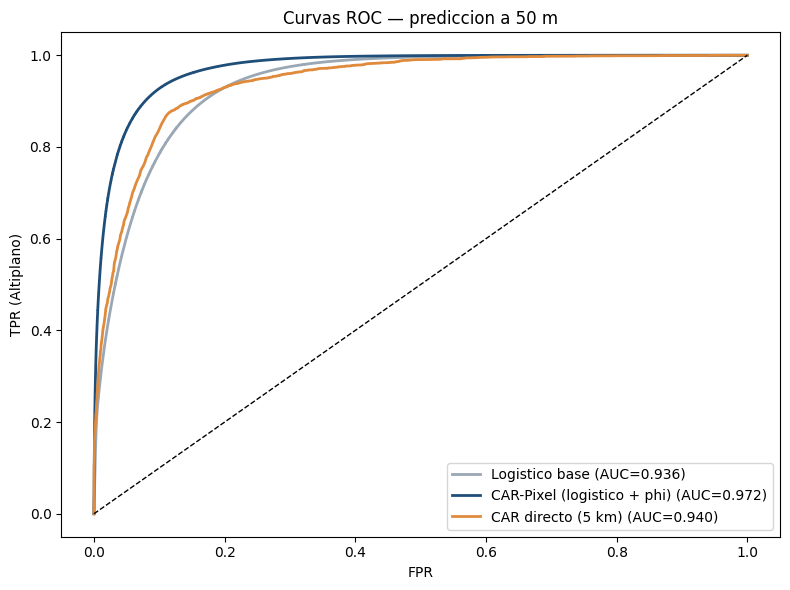

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for p, nombre, color in [(pb, "Logistico base", "#9aa7b4"),
                          (pc, "CAR-Pixel (logistico + phi)", "#1f4e79"),
                          (pd_vals[pd_mask], "CAR directo (5 km)", "#e08a3c")]:
    y_roc = y_all if len(p) == len(y_all) else y_all[pd_mask]
    fpr, tpr, _ = roc_curve(y_roc, p, pos_label=1)
    auc = roc_auc_score(y_roc, p)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{nombre} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR (Altiplano)")
ax.set_title("Curvas ROC — prediccion a 50 m")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_roc_comparacion.png"), dpi=150)
plt.show()

## 6. Mapas de predicción

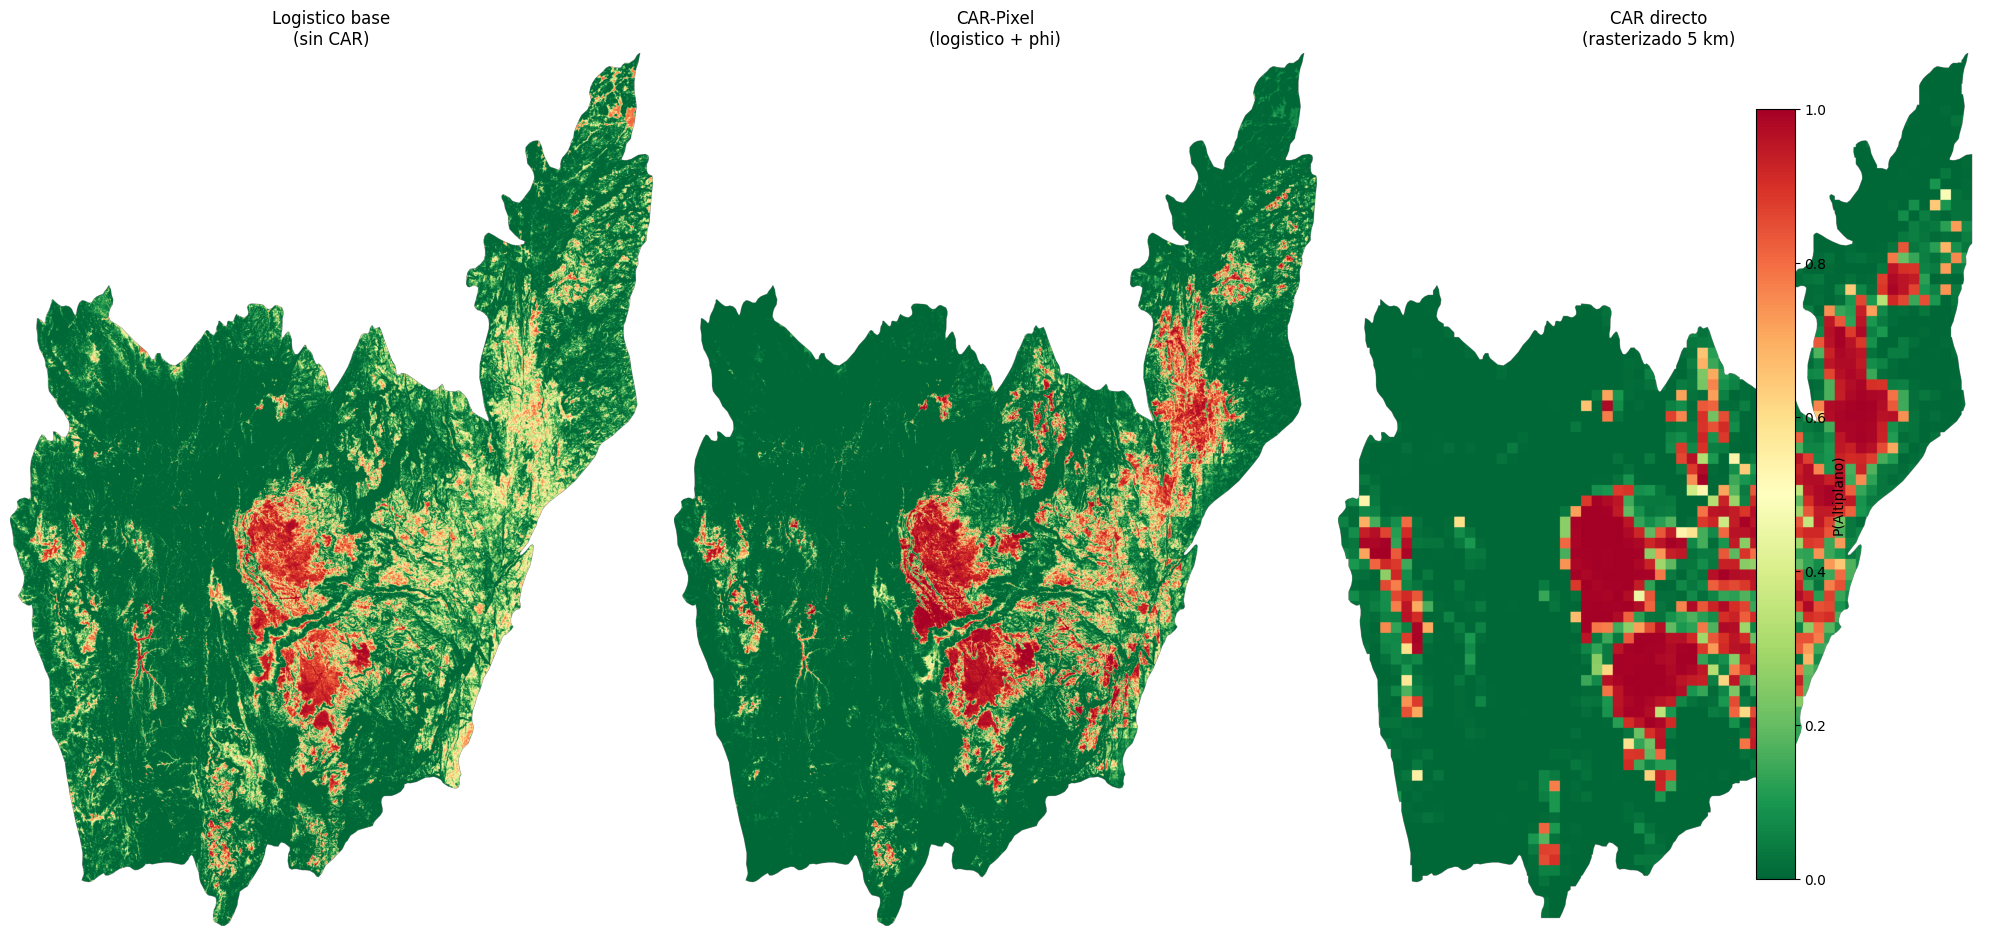

In [9]:
izq, abj, der, arr = array_bounds(ref_shape[0], ref_shape[1], ref_transform)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, mapa, titulo in zip(axes,
        [prob_base_full, prob_carpx_full, prob_car_directo],
        ["Logistico base\n(sin CAR)", "CAR-Pixel\n(logistico + phi)", "CAR directo\n(rasterizado 5 km)"]):
    im = ax.imshow(mapa, cmap="RdYlGn_r", vmin=0, vmax=1,
                   extent=(izq, der, abj, arr))
    ax.set_title(titulo); ax.set_axis_off()
plt.colorbar(im, ax=axes, label="P(Altiplano)", fraction=0.025)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "02_mapas_probabilidad.png"), dpi=150)
plt.show()

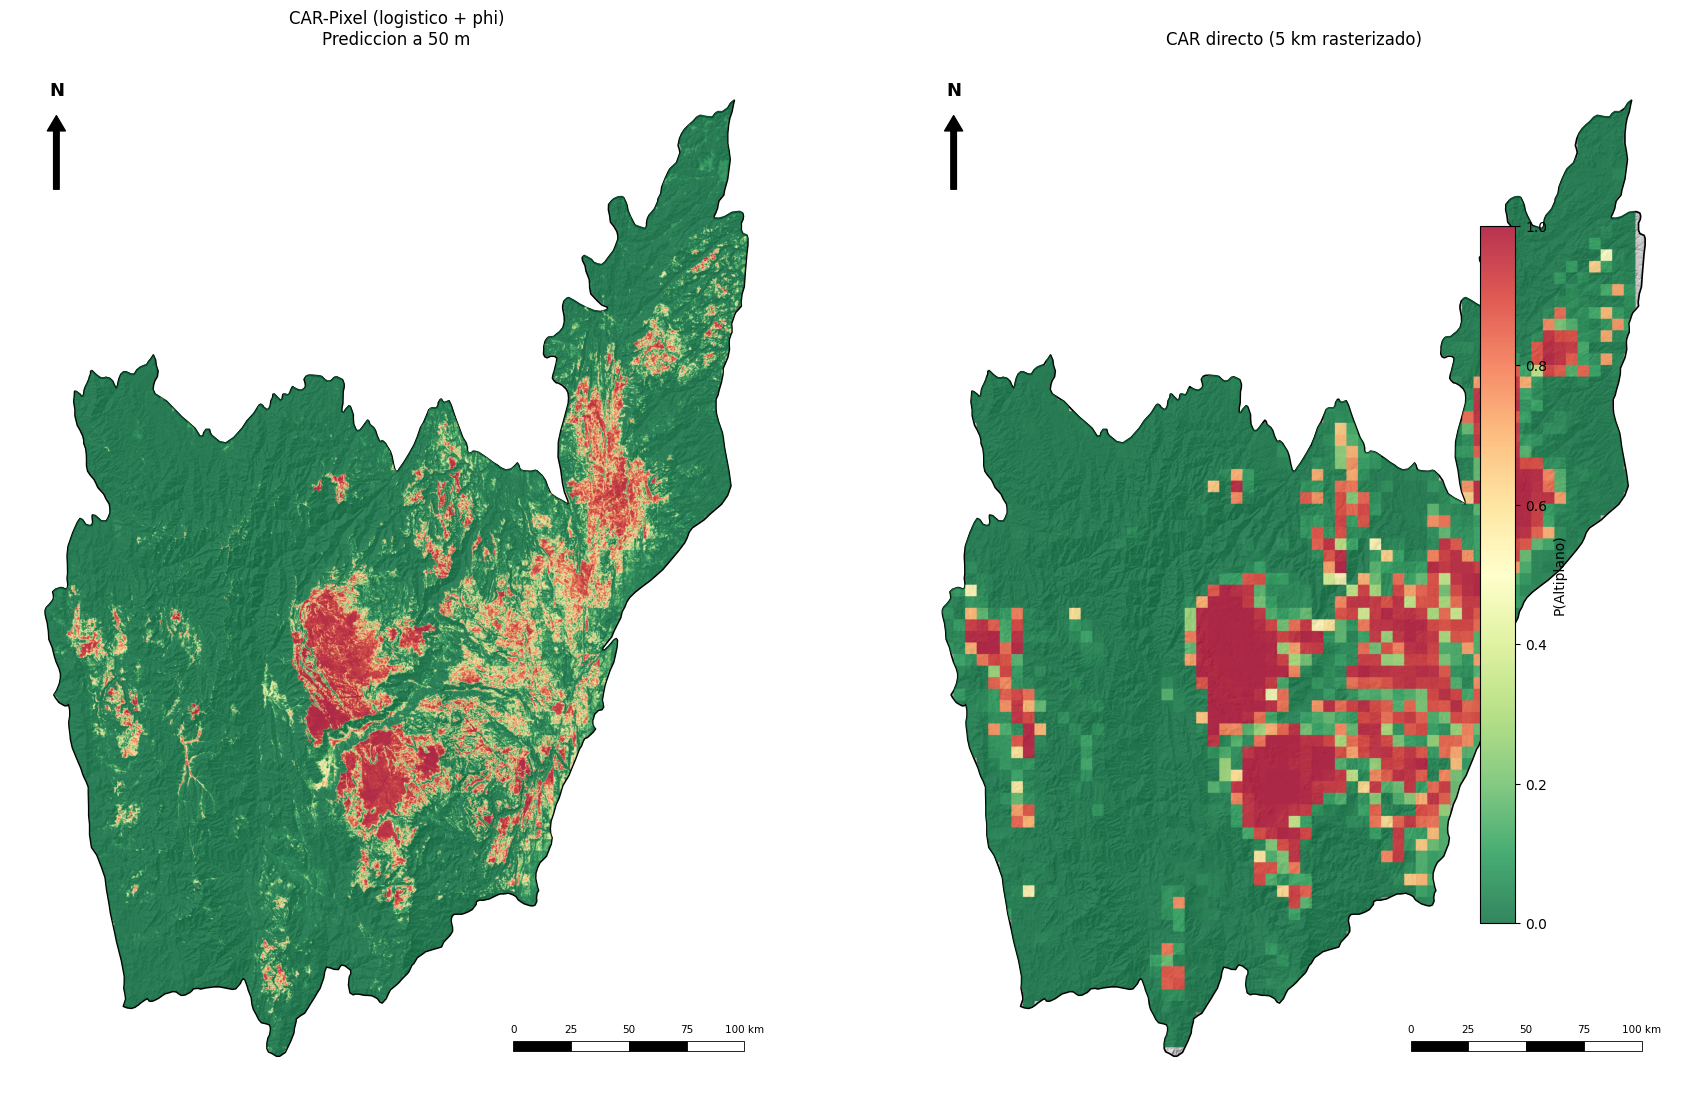

In [10]:
import sys
sys.path.insert(0, os.path.join(RAIZ, "Codigo"))
from plantilla_mapas import aplicar_plantilla_mapa, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "11_CAR_prediccion_total_v2")
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 11))
for ax, mapa, titulo in zip(axes,
        [prob_carpx_full, prob_car_directo],
        ["CAR-Pixel (logistico + phi)\nPrediccion a 50 m",
         "CAR directo (5 km rasterizado)"]):
    aplicar_plantilla_mapa(ax)
    im = ax.imshow(mapa, cmap="RdYlGn_r", vmin=0, vmax=1,
                   extent=(izq, der, abj, arr), alpha=0.8, zorder=5)
    ax.set_title(titulo); ax.set_axis_off()
plt.colorbar(im, ax=axes, label="P(Altiplano)", fraction=0.025)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "02_mapas_probabilidad.png"), dpi=150)
plt.show()

## 7. Exportación de la predicción a 50 m

In [11]:
perfil_salida = {
    "driver": "GTiff", "height": ref_shape[0], "width": ref_shape[1], "count": 1,
    "dtype": "float32", "crs": ref_crs, "transform": ref_transform,
    "nodata": np.nan, "compress": "lzw",
}

ruta_pred = os.path.join(CARPETA_RESULTADOS, "prediccion_altiplano_CAR_v2.tif")
with rasterio.open(ruta_pred, "w", **perfil_salida) as dst:
    dst.write(prob_carpx_full.astype(np.float32), 1)

print(f"Prediccion CAR-Pixel exportada: {ruta_pred}")
print(f"  Resolucion: {abs(ref_transform.a):.0f} m (igual al DEM)")
print(f"  Forma: {ref_shape}")
print(f"  Pixeles con prediccion: {np.isfinite(prob_carpx_full).sum():,}")
print(f"\nCapa phi CAR ya exportada en: {os.path.join(CARPETA_RESULTADOS, 'car_phi_50m_v2.tif')}")
print(f"\nTIEMPO TOTAL: {time.time()-t_inicio:.0f} s")

Prediccion CAR-Pixel exportada: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\prediccion_altiplano_CAR_v2.tif
  Resolucion: 50 m (igual al DEM)
  Forma: (8276, 6084)
  Pixeles con prediccion: 24,783,966

Capa phi CAR ya exportada en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\car_phi_50m_v2.tif

TIEMPO TOTAL: 365 s
